In [15]:
# Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os

Análise Exploratória

In [16]:
# Importando o conjunto de dados
from google.colab import drive
drive.mount('/content/drive')

# Assuming 'WineQT.csv' is in the root of 'My Drive'
df = pd.read_csv('/content/drive/My Drive/WineQT.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
# Visualizando as primeiras informações para entender a composição da base
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
None
   fixed acidity  volatile acidity  citric acid  residual sugar  chlor

In [18]:
# Transformação da variável alvo (quality) em classificação binária
# 1 representa 'Alta Qualidade' (nota >= 7) e 0 representa 'Baixa/Média Qualidade' (nota < 7)
df['quality_bin'] = df['quality'].apply(lambda x: 1 if x >= 7 else 0)

In [19]:
# Analisando o balanceamento das classes criadas
print("Balanceamento das classes:")
print(df['quality_bin'].value_counts())

Balanceamento das classes:
quality_bin
0    984
1    159
Name: count, dtype: int64


In [20]:
# Verificando a quantidade de dados nulos por coluna
print("Dados nulos em cada coluna:\n", df.isnull().sum())
# Verificando se existem linhas duplicadas
print("\nTotal de dados duplicados: ", df.duplicated().sum())

Dados nulos em cada coluna:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
quality_bin             0
dtype: int64

Total de dados duplicados:  0


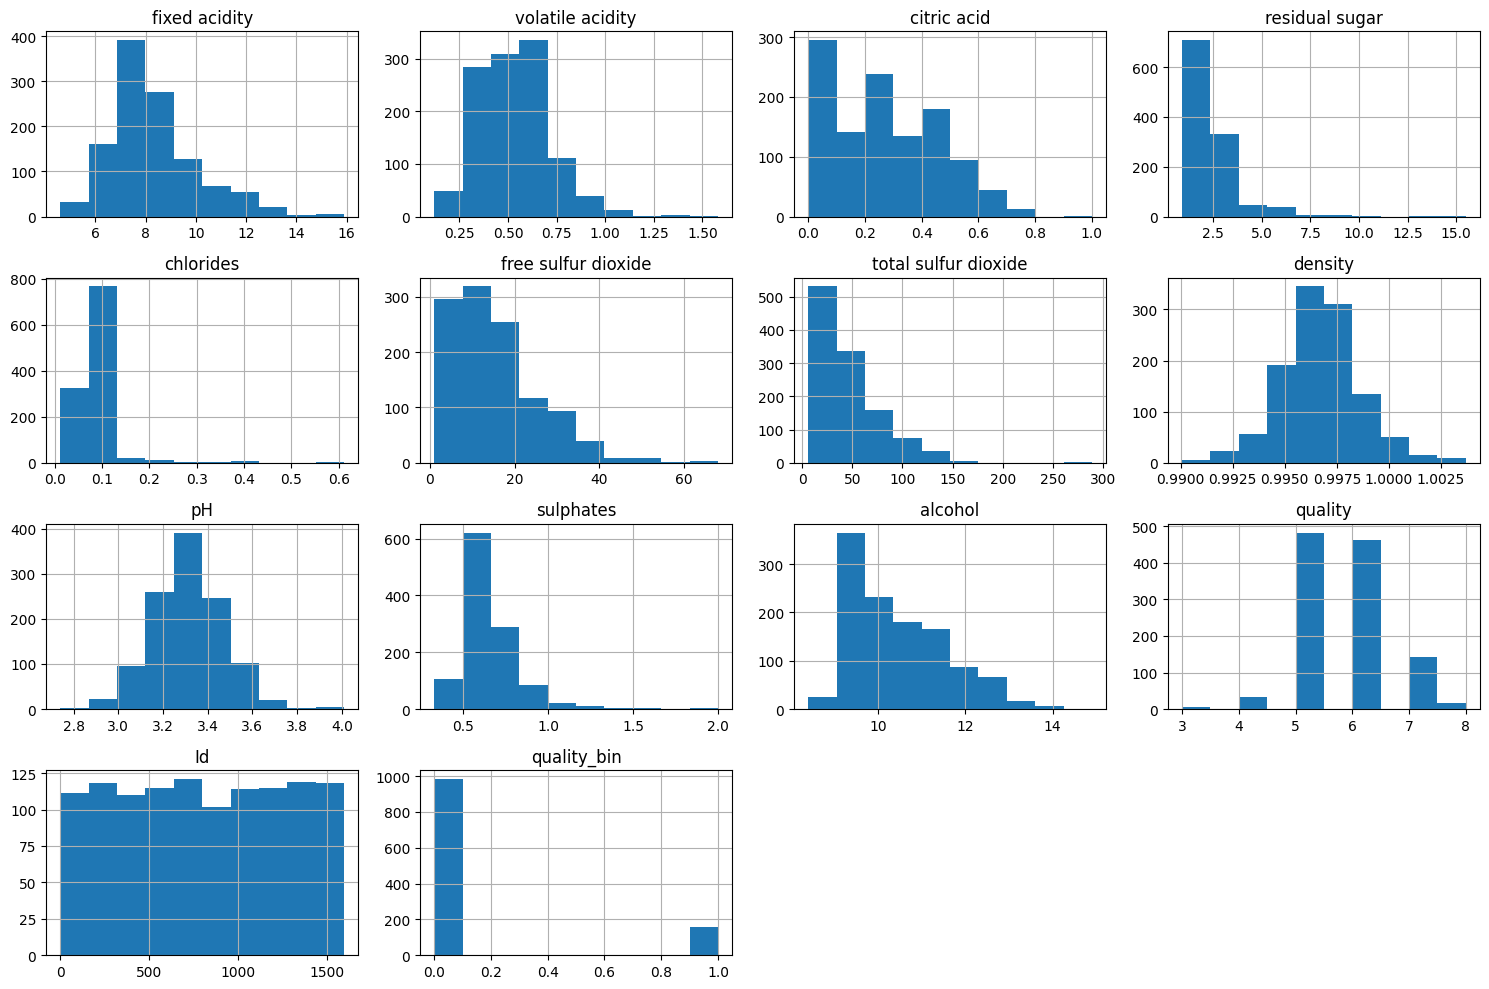

In [21]:
# Distribuição das Variáveis
df.hist(figsize=(15, 10))
plt.tight_layout()
plt.show()

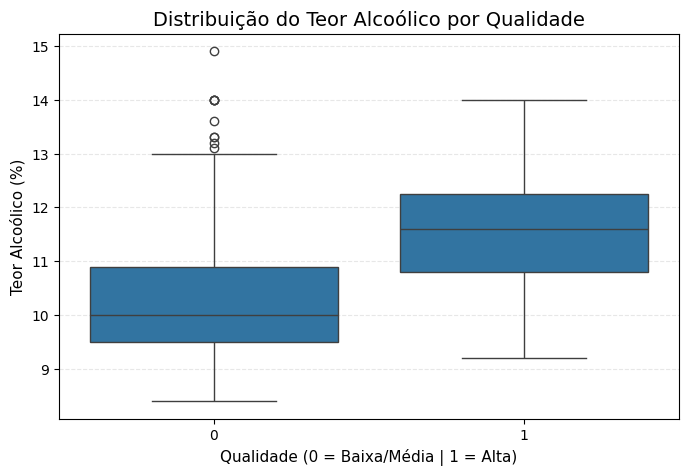

In [22]:
# Gráfico de Dispersão: Teor Alcoólico vs Qualidade Binária
plt.figure(figsize=(8,5))

sns.boxplot(
    x='quality_bin',
    y='alcohol',
    data=df
)

plt.title('Distribuição do Teor Alcoólico por Qualidade', fontsize=14)
plt.xlabel('Qualidade (0 = Baixa/Média | 1 = Alta)', fontsize=11)
plt.ylabel('Teor Alcoólico (%)', fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

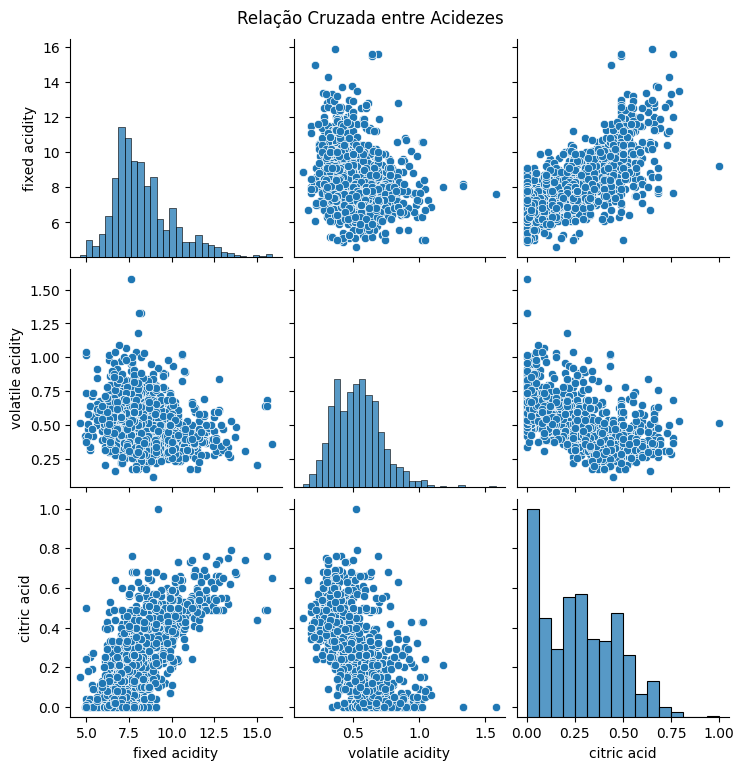

In [23]:
#  Análise de Acidezes (Pairplot focado)
acid_cols = ['fixed acidity', 'volatile acidity', 'citric acid']
sns.pairplot(df[acid_cols])
plt.suptitle("Relação Cruzada entre Acidezes", y=1.02)
plt.show()

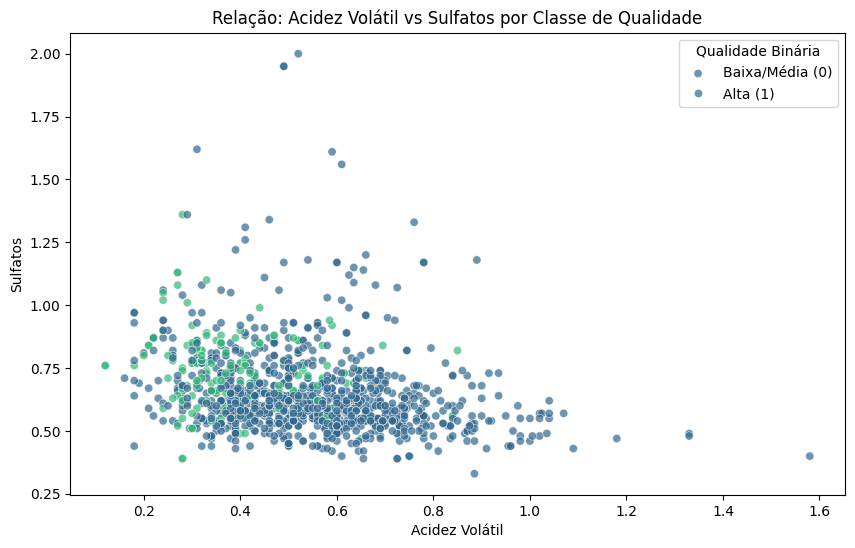

In [24]:
#  Gráfico de Dispersão: Acidez Volátil vs Sulfatos (Separado por Qualidade)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='volatile acidity', y='sulphates', hue='quality_bin', data=df, palette='viridis', alpha=0.7)
plt.title("Relação: Acidez Volátil vs Sulfatos por Classe de Qualidade")
plt.xlabel("Acidez Volátil")
plt.ylabel("Sulfatos")
plt.legend(title='Qualidade Binária', labels=['Baixa/Média (0)', 'Alta (1)'])
plt.show()

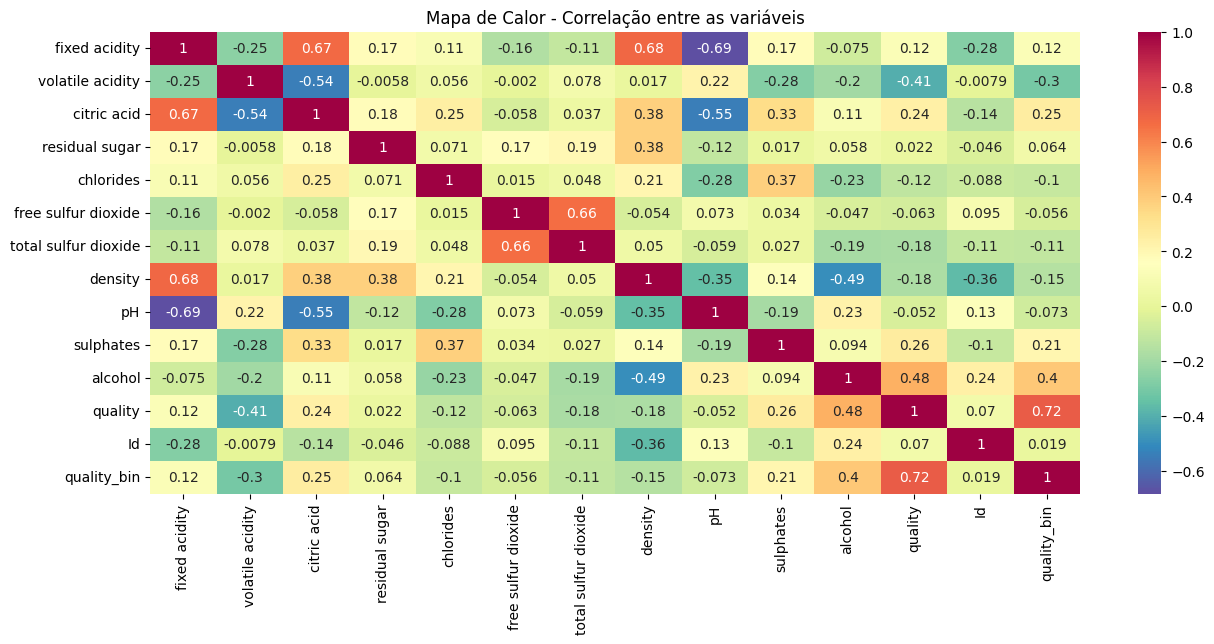

In [25]:
# Identificação de Correlações
# O heatmap permite entender com eficiência quais variáveis estão fortemente correlacionadas
plt.figure(figsize=(15, 6))
corr = sns.heatmap(df.corr(), annot=True, cmap="Spectral_r")
plt.title("Mapa de Calor - Correlação entre as variáveis")
plt.show()

In [26]:
df.to_csv('dataset_tratado.csv', index=False)

In [27]:
from google.colab import files
files.download('dataset_tratado.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>